In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

DATASET_ROOT = Path("26045171/Object_Detection/coco")

In [2]:
def find_unannotated(split):
    ann_file = DATASET_ROOT / split / f"{split}_annotations.json"
    with open(ann_file) as f:
        coco = json.load(f)
    annotated_ids = {a["image_id"] for a in coco["annotations"]}
    return [
        {"split": split, "id": img["id"], "file_name": img["file_name"]}
        for img in coco["images"]
        if img["id"] not in annotated_ids
    ]

unannotated = find_unannotated("train") + find_unannotated("valid")

print(f"Total unannotated: {len(unannotated)}")
for u in unannotated:
    print(f"  [{u['split']:5s}] id={u['id']:5d}  {u['file_name']}")

Total unannotated: 9
  [train] id=   85  100867.jpg
  [train] id=   92  100328.jpg
  [train] id=  182  100859.jpg
  [train] id=  549  100978.jpg
  [train] id=  688  100197.jpg
  [train] id=  944  100310.jpg
  [train] id= 1015  100195.jpg
  [valid] id=   91  101186.jpg
  [valid] id=  193  100953.jpg


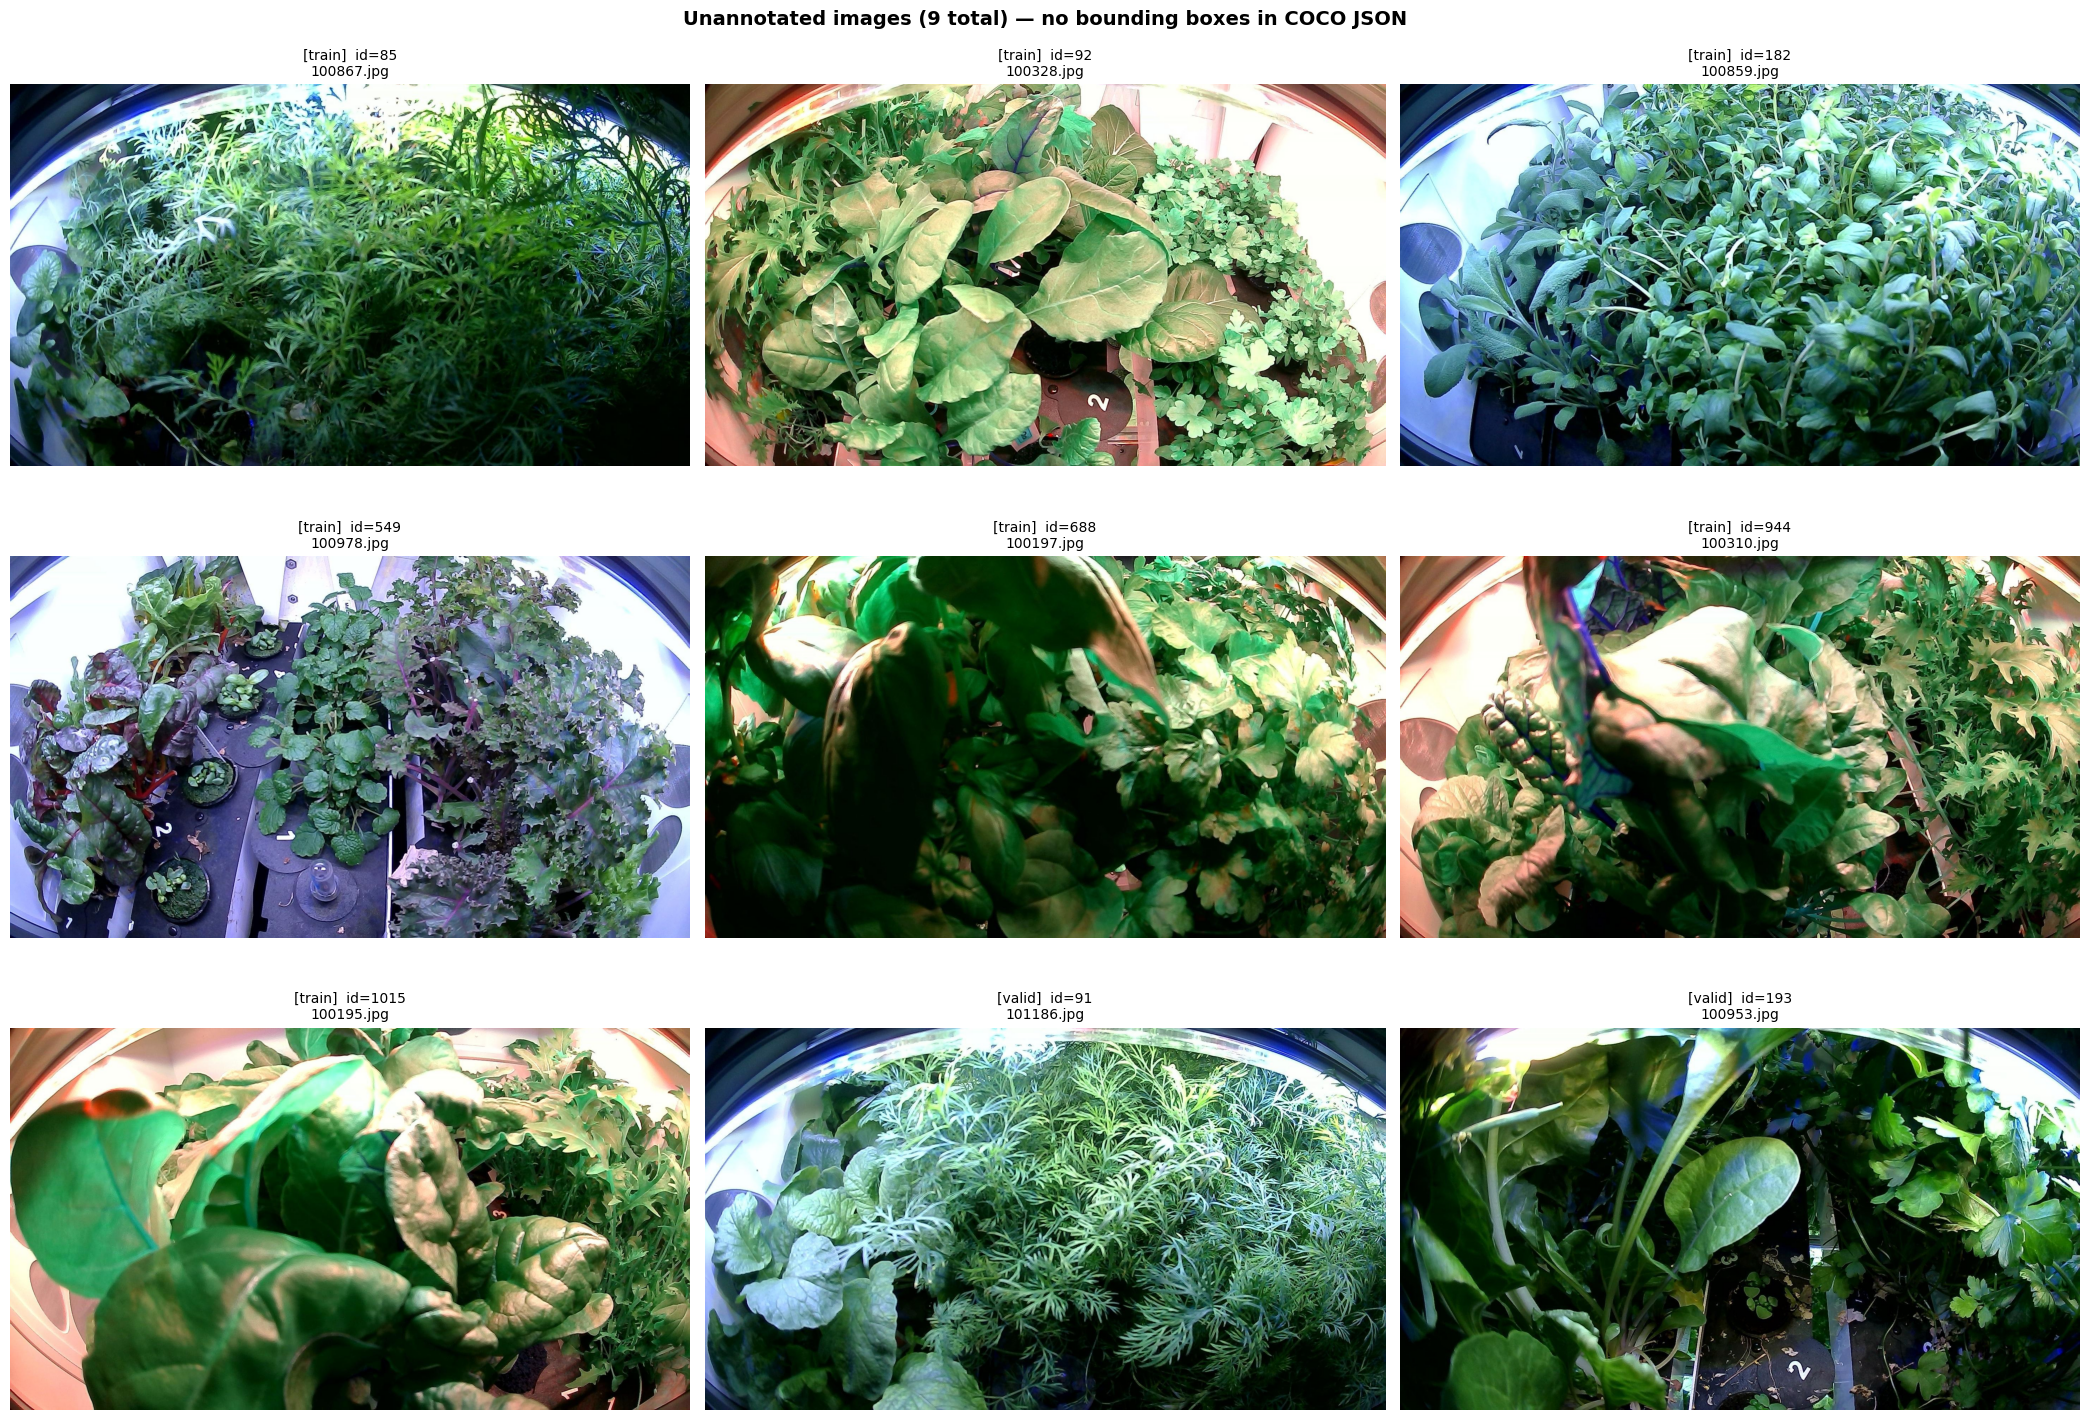

In [3]:
n = len(unannotated)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes = axes.flatten()

for ax, entry in zip(axes, unannotated):
    img_path = DATASET_ROOT / entry["split"] / entry["file_name"]
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(
        f"[{entry['split']}]  id={entry['id']}\n{entry['file_name']}",
        fontsize=10
    )
    ax.axis("off")

# hide any unused axes
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle(
    f"Unannotated images ({n} total) — no bounding boxes in COCO JSON",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("unannotated_images.png", dpi=120, bbox_inches="tight")
plt.show()